# Discussion on spurious metrics + plots from paper

This is a short notebook highlighting the spurious variance example included in the current paper. The spurious variance is given by the following formula,
$$
    V(X) = 1 + \frac{1}{d}\sum_{l=1}^d\sum_{l'\ne l}^d\rho_{ll'},
$$
where $X\sim\mathcal{N}(0,1)^d$ and $\rho_{ll'} = \mathbb{E}[X_lX_{l'}]$. We note that following the work of Kucherenko, Sergei & Asotsky, Danil & Atanassov, E. & Roy, Pamphile. (2021), $X$ is assumed to be a normal random variable, that is $X\sim\mathcal{N}(0,1)^d$, of course if the variable we are interested in, say $Y$ is not normal, then all we need to do is apply a sufficient transformation $\Phi$, such that $\Phi(Y)\sim\mathcal{N}(0,1)$.

Using this metric gives us the desired plots and graphs, which will allow us to highlight Tenokonda's Sobol' sequences perfomance in quasi-Monte Carlo simulations.

In [1]:
import numpy as np

In [2]:
from tklds.interface.generators import generate_lds_rvs, get_sequence_enum
from tklds.interface.processes import spurious_variance_prefix
from plotting_helper import plot_with_error_panel

In [3]:
n = 1023
n_skip = 1
tk_dim_max = 50000
jk_dim_max = 21021

In [4]:
sequence_enum = get_sequence_enum()
tk_u = generate_lds_rvs(sequence_enum.TKRG_A_AP5, n=n, d=tk_dim_max)[n_skip:]

In [5]:
tk_spv = spurious_variance_prefix(tk_u)

In [6]:
jk_u = generate_lds_rvs(sequence_enum.NEW_JOE_KUO, n=n, d=jk_dim_max)[n_skip:]

In [7]:
jk_spv = spurious_variance_prefix(jk_u)

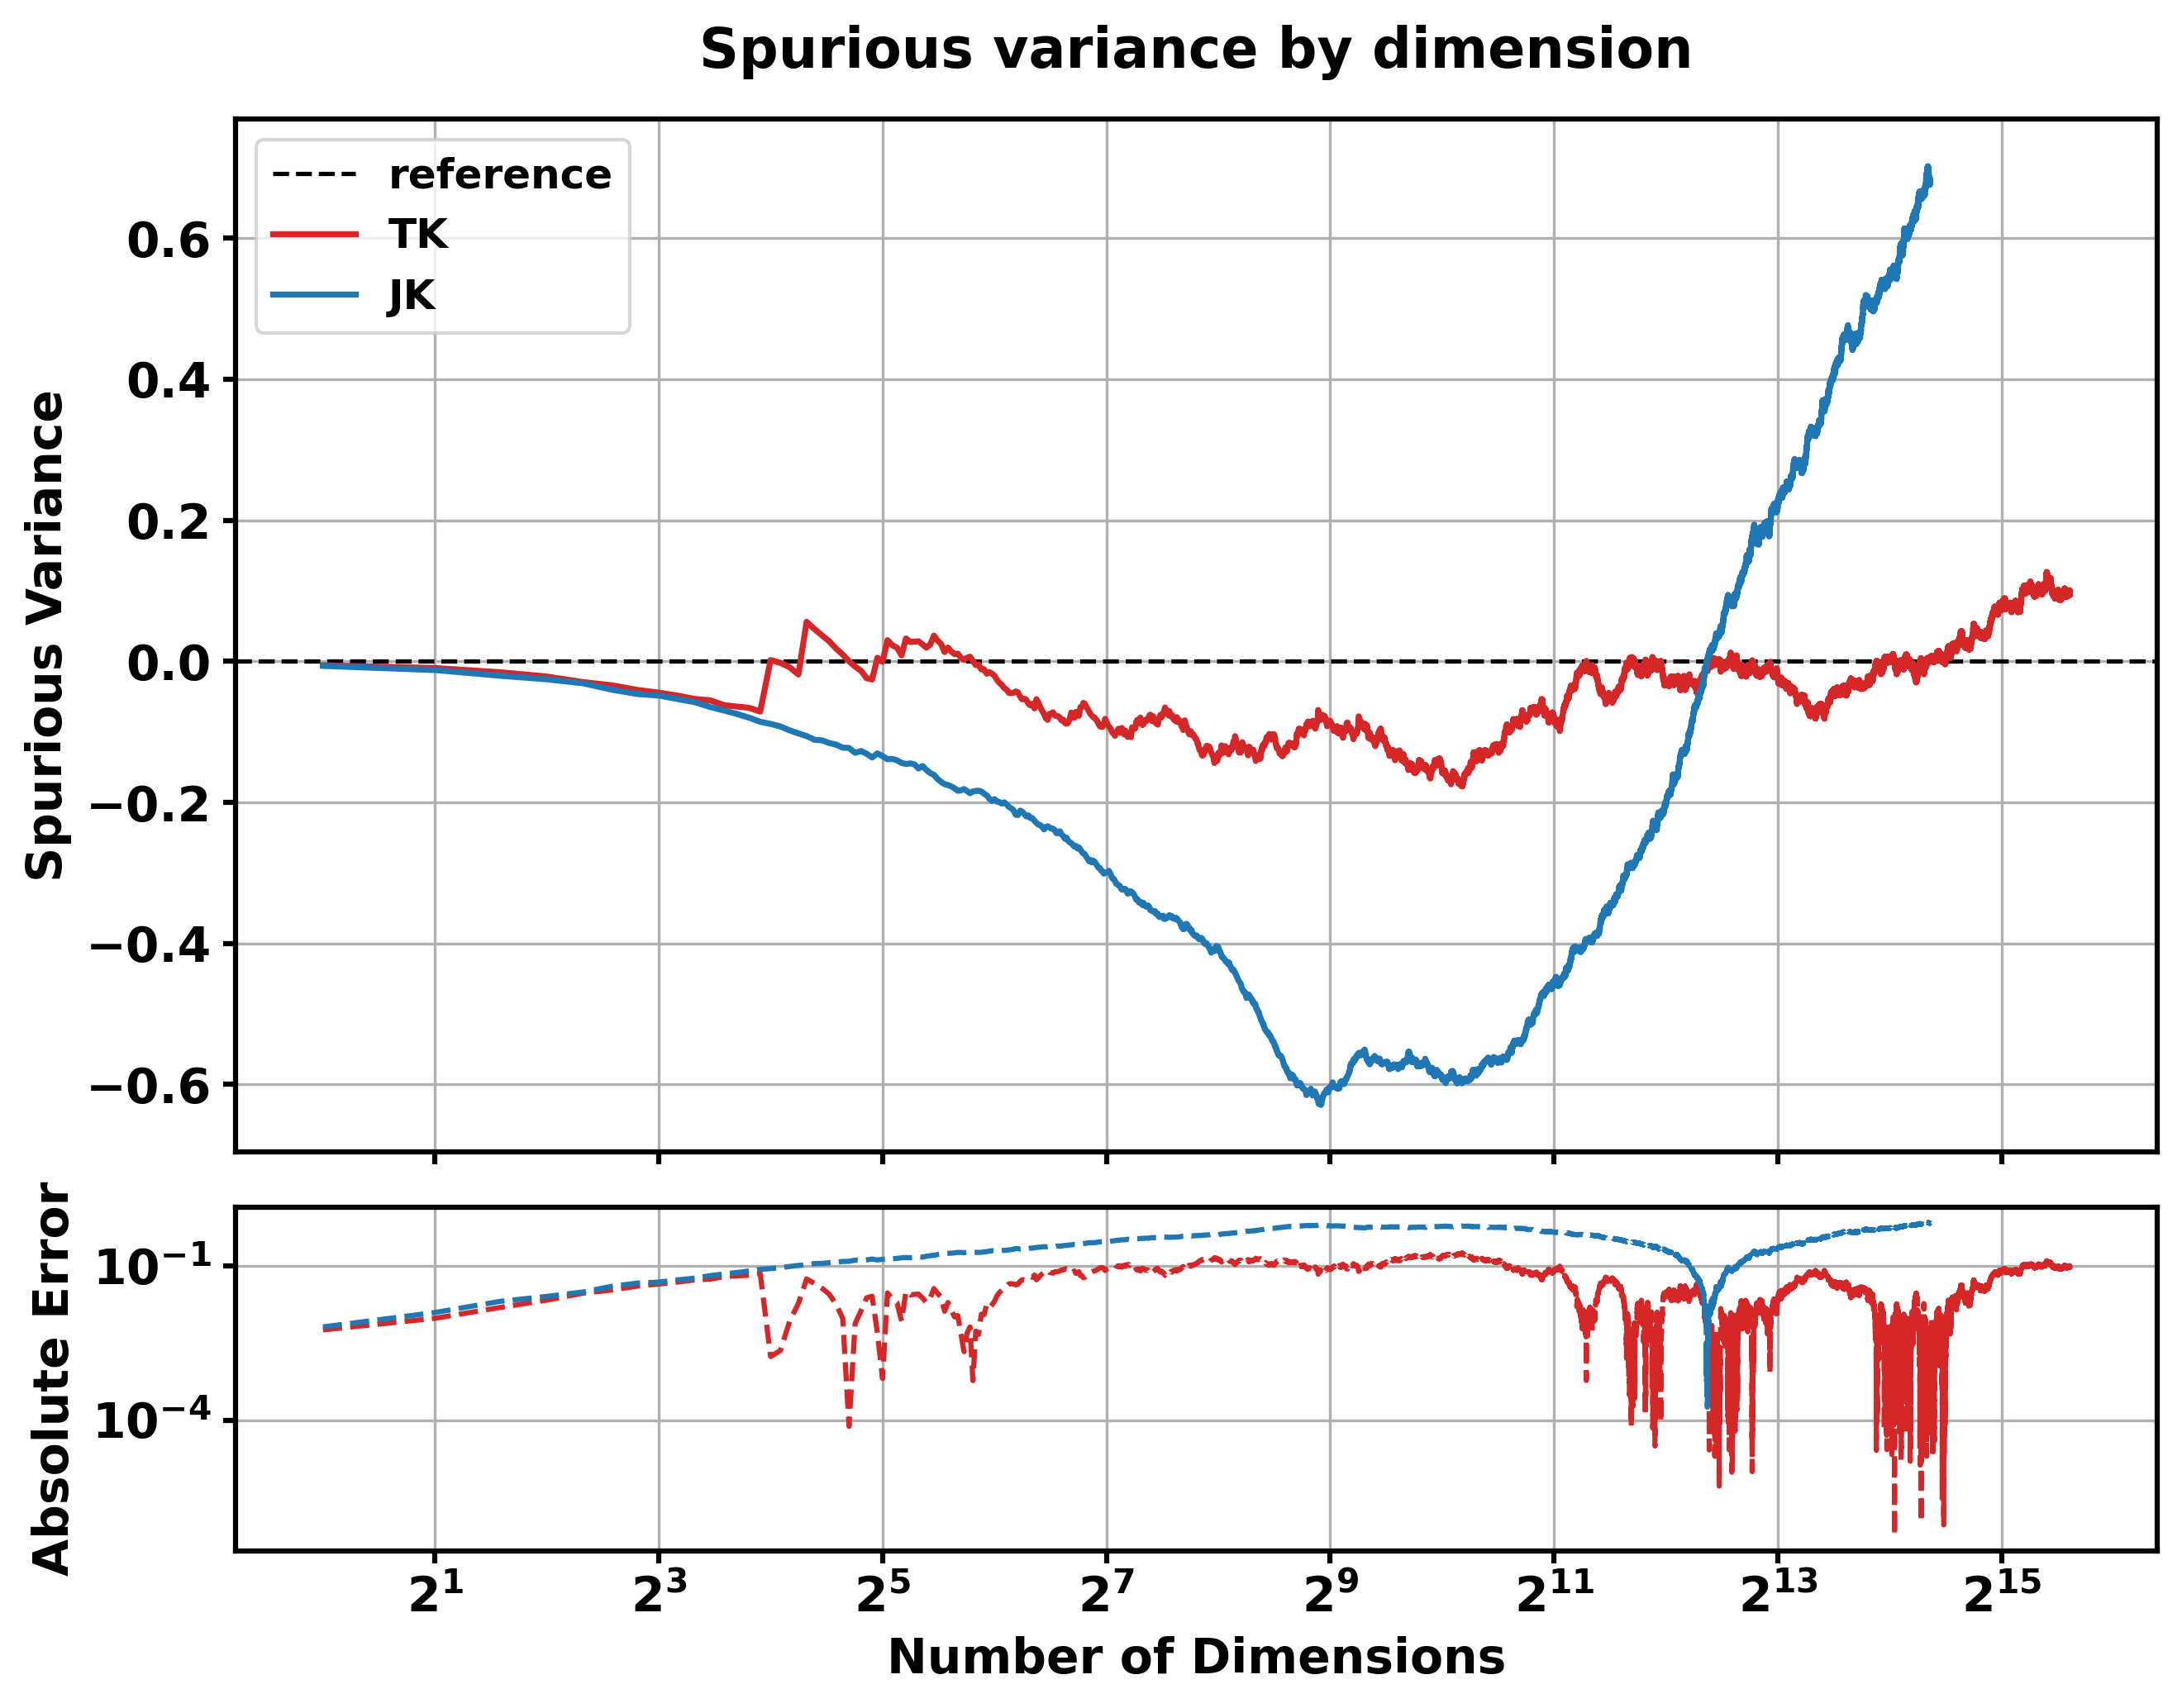

(<Figure size 3000x2250 with 2 Axes>,
 (<Axes: title={'center': 'Spurious variance by dimension'}, ylabel='Spurious Variance'>,
  <Axes: xlabel='Number of Dimensions', ylabel='Absolute Error'>))

In [8]:
x_data = [np.arange(1, tk_dim_max), np.arange(1, jk_dim_max)]
plot_with_error_panel(x_data = x_data,
                      y_data = [tk_spv, jk_spv],
                      y_axis_label_top = 'Spurious Variance',
                      y_axis_label_bottom='Absolute Error',
                      x_axis_label='Number of Dimensions',
                      y_data_label=['TK', 'JK'],
                      y_data_colors=['tab:red', 'tab:blue'],
                      reference_x_data=x_data[0],
                      reference_y_data=0.0,
                      title='Spurious variance by dimension',)

In [31]:
sequence_enum.TKRG_A_AP5

<SequenceNum.TKRG_A_AP5: 'tkrg-a-ap5'>